场景 A (H上限=10, L上限=8): 无解 (曲线平行或发散)
场景 B (H截断于7, L上限=8): 找到解: a*=5.2024, r=6.2058


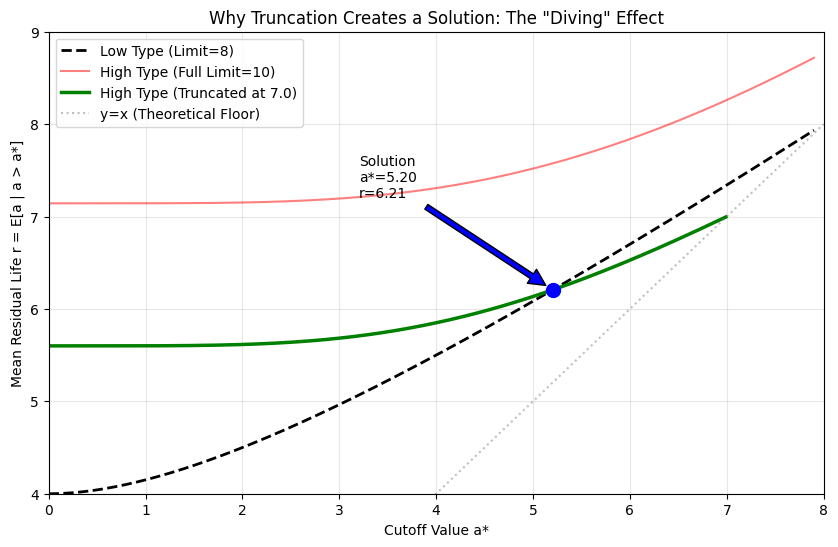

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, uniform
from scipy.integrate import quad
from scipy.optimize import brentq

# ==========================================
# 1. 核心计算函数
# ==========================================

def get_mean_residual_life(a_star, dist_cdf, limit):
    """
    计算给定分布在 a > a_star 条件下的期望值 (Mean Residual Life)。
    公式: E[a | a > a*] = a* + (Integral_{a*}^{limit} (1 - F(x)) dx) / (1 - F(a*))
    对于截断分布，我们需要用到重整化逻辑，但在计算期望时，
    使用 a* + (Integral_{a*}^{limit} (F(limit) - F(x)) dx) / (F(limit) - F(a*)) 更稳健。
    """
    if a_star >= limit - 1e-6:
        return limit # 碰到上限，期望就是上限本身

    # F_limit 是归一化常数。如果分布没被截断，这就是 1。
    F_limit = dist_cdf(limit)
    F_astar = dist_cdf(a_star)

    denominator = F_limit - F_astar
    if denominator <= 1e-9:
        return limit

    # 积分部分：从 a* 积到 limit
    # 被积函数是 P(X > x | X < limit) 的未归一化形式： F(limit) - F(x)
    integral_val, _ = quad(lambda x: F_limit - dist_cdf(x), a_star, limit)

    return a_star + integral_val / denominator

def find_equilibrium(cdf_h, cdf_l, limit_h, limit_l):
    """
    寻找交点。返回 (a_star, r)。
    """
    # 目标函数：两者之差
    def objective(x):
        return get_mean_residual_life(x, cdf_h, limit_h) - \
               get_mean_residual_life(x, cdf_l, limit_l)

    # 搜索范围：从 0 到 两个上限中较小的那个
    search_limit = min(limit_h, limit_l) - 0.01

    try:
        # brentq 是非常稳健的寻根算法，要求区间两端符号相反
        root = brentq(objective, 0, search_limit)
        r_val = get_mean_residual_life(root, cdf_h, limit_h)
        return root, r_val
    except ValueError:
        return None, None # 无解（没有符号反转）

# ==========================================
# 2. 场景设置
# ==========================================

# 场景 A: 无解情况 (FOSD)
# H: Beta(5,2)*10 (均值高，上限 10)
# L: Beta(2,2)*8  (均值低，上限 8)
# H 既好又长，完全压制 L。
dist_h_full = lambda x: beta.cdf(x/10, 5, 2) if x < 10 else 1
limit_h_full = 10

dist_l = lambda x: beta.cdf(x/8, 2, 2) if x < 8 else 1
limit_l = 8

# 场景 B: 你的截断策略
# 强行把 H 截断在 7.0
limit_h_truncated = 7.0
# 注意：CDF 函数本身不用变，但在计算期望时，我们会把 7.0 视为上限
# get_mean_residual_life 函数会自动处理归一化 (F(7) - F(x))

# ==========================================
# 3. 运行计算
# ==========================================

# 计算场景 A
sol_a, sol_a_r = find_equilibrium(dist_h_full, dist_l, limit_h_full, limit_l)

# 计算场景 B
sol_b, sol_b_r = find_equilibrium(dist_h_full, dist_l, limit_h_truncated, limit_l)

print(f"场景 A (H上限=10, L上限=8): {'找到解: ' + str(round(sol_a, 4)) if sol_a else '无解 (曲线平行或发散)'}")
print(f"场景 B (H截断于7, L上限=8): {'找到解: a*=' + str(round(sol_b, 4)) + ', r=' + str(round(sol_b_r, 4)) if sol_b else '无解'}")

# ==========================================
# 4. 画图 (最重要的一步)
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

# 生成 x 轴数据点
x_vals = np.linspace(0, 7.9, 200) # 画到 7.9 即可，接近 L 的上限

# 1. 画 L 的曲线 (基准线)
y_l = [get_mean_residual_life(x, dist_l, limit_l) for x in x_vals]
ax.plot(x_vals, y_l, label=f'Low Type (Limit={limit_l})', color='black', linestyle='--', linewidth=2)

# 2. 画 H (原始) 的曲线
y_h_full = [get_mean_residual_life(x, dist_h_full, limit_h_full) for x in x_vals]
ax.plot(x_vals, y_h_full, label=f'High Type (Full Limit={limit_h_full})', color='red', alpha=0.5)

# 3. 画 H (截断) 的曲线 - 你的策略！
# 注意：这个曲线只能画到 7.0
x_vals_trunc = np.linspace(0, limit_h_truncated - 0.01, 150)
y_h_trunc = [get_mean_residual_life(x, dist_h_full, limit_h_truncated) for x in x_vals_trunc]
ax.plot(x_vals_trunc, y_h_trunc, label=f'High Type (Truncated at {limit_h_truncated})', color='green', linewidth=2.5)

# 4. 画 y=x 对角线 (参考线)
ax.plot([0, 8], [0, 8], color='gray', linestyle=':', alpha=0.5, label='y=x (Theoretical Floor)')

# 5. 标注交点
if sol_b:
    ax.scatter([sol_b], [sol_b_r], color='blue', s=100, zorder=5)
    ax.annotate(f'Solution\na*={sol_b:.2f}\nr={sol_b_r:.2f}',
                xy=(sol_b, sol_b_r), xytext=(sol_b-2, sol_b_r+1),
                arrowprops=dict(facecolor='blue', shrink=0.05))

ax.set_xlabel('Cutoff Value a*')
ax.set_ylabel('Mean Residual Life r = E[a | a > a*]')
ax.set_title('Why Truncation Creates a Solution: The "Diving" Effect')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(4, 9) # 设置一下 y 轴范围方便观察
ax.set_xlim(0, 8)

plt.show()

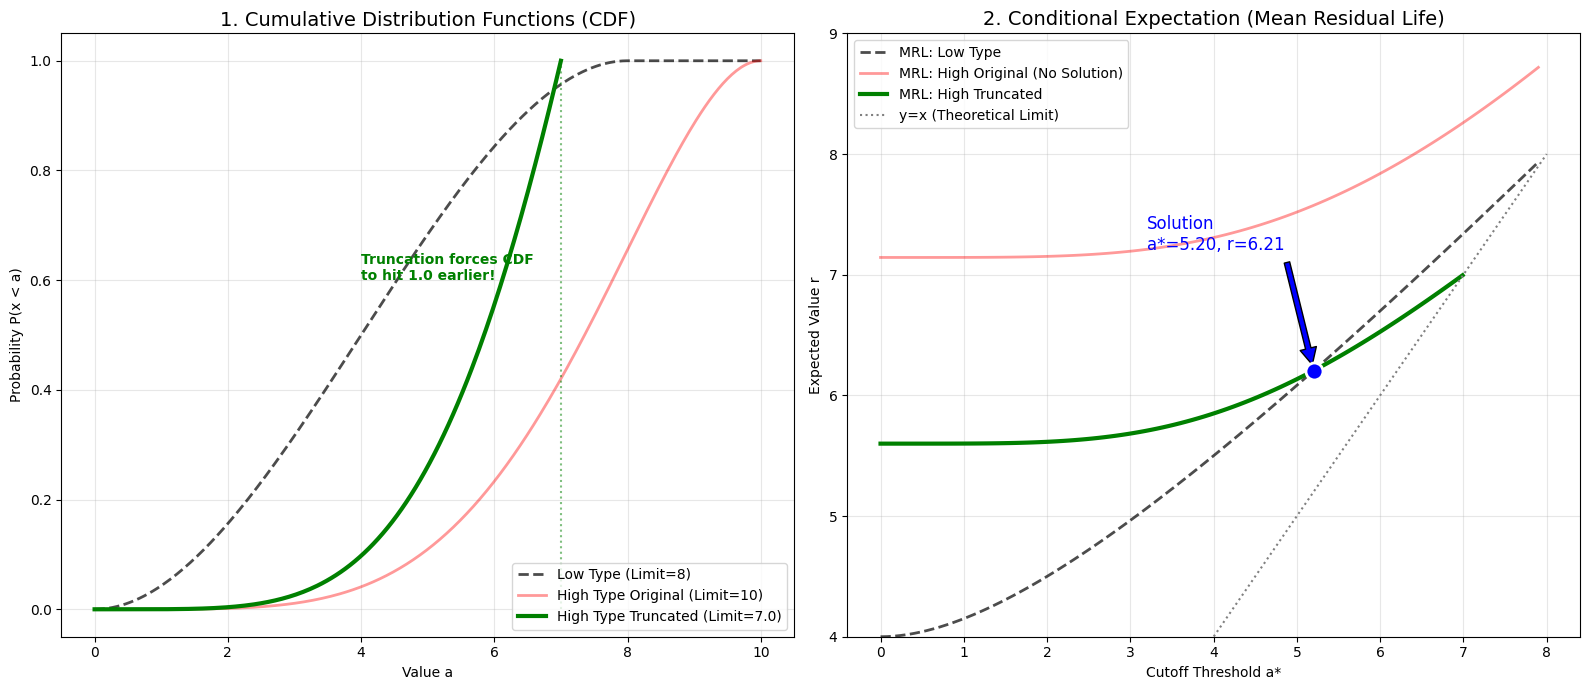

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.integrate import quad
from scipy.optimize import brentq

# ==========================================
# 1. 定义分布与参数
# ==========================================

# 场景设置
# L: Beta(2,2) * 8  (较弱，但尾巴长)
# H_orig: Beta(5,2) * 10 (很强，FOSD，无解)
# H_trunc: H_orig 截断在 7.0

LIMIT_L = 8.0
LIMIT_H_ORIG = 10.0
LIMIT_H_TRUNC = 7.0

# 定义原始 CDF 函数
def cdf_l_func(x):
    if x < 0: return 0
    if x >= LIMIT_L: return 1
    return beta.cdf(x / LIMIT_L, 2, 2)

def cdf_h_orig_func(x):
    if x < 0: return 0
    if x >= LIMIT_H_ORIG: return 1
    return beta.cdf(x / LIMIT_H_ORIG, 5, 2)

# 定义截断后的 H CDF (需要重新归一化)
# F_new(x) = F_old(x) / F_old(Limit)
normalization_constant = cdf_h_orig_func(LIMIT_H_TRUNC)

def cdf_h_trunc_func(x):
    if x < 0: return 0
    if x >= LIMIT_H_TRUNC: return 1
    # 归一化核心逻辑
    val = cdf_h_orig_func(x) / normalization_constant
    return min(val, 1.0)

# ==========================================
# 2. 核心计算逻辑 (Mean Residual Life)
# ==========================================

def get_mrl(a_star, cdf_func, limit):
    """计算 E[a | a > a*]"""
    if a_star >= limit - 1e-4:
        return limit # 碰到上限

    # 1. 计算分母 P(a > a*)
    # 注意：传入的 cdf_func 已经是归一化的，所以 cdf(limit) = 1
    prob_survival = 1.0 - cdf_func(a_star)

    if prob_survival <= 1e-9:
        return limit

    # 2. 计算分子 Integral (1 - F(x)) dx
    # 数学原理：期望 E[X] = Integral(1-F(x))
    # 条件期望分子 = Integral_a*^limit (1 - F(x)) dx
    integral_val, _ = quad(lambda x: 1.0 - cdf_func(x), a_star, limit)

    return a_star + integral_val / prob_survival

# ==========================================
# 3. 求解交点
# ==========================================

def find_solution():
    def objective(x):
        return get_mrl(x, cdf_h_trunc_func, LIMIT_H_TRUNC) - \
               get_mrl(x, cdf_l_func, LIMIT_L)

    try:
        # 在 0 到 6.99 之间寻找交点
        root = brentq(objective, 0, LIMIT_H_TRUNC - 0.01)
        r_val = get_mrl(root, cdf_h_trunc_func, LIMIT_H_TRUNC)
        return root, r_val
    except ValueError:
        return None, None

sol_a, sol_r = find_solution()

# ==========================================
# 4. 绘图 (双子图)
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- 图 1: CDF 对比 ---

x_range_full = np.linspace(0, 10, 300)
x_range_trunc = np.linspace(0, LIMIT_H_TRUNC, 200)

# 画 L (黑虚线)
ax1.plot(x_range_full, [cdf_l_func(x) for x in x_range_full],
         'k--', lw=2, label='Low Type (Limit=8)', alpha=0.7)

# 画 H 原始 (红线)
ax1.plot(x_range_full, [cdf_h_orig_func(x) for x in x_range_full],
         'r-', lw=2, label='High Type Original (Limit=10)', alpha=0.4)

# 画 H 截断 (绿实线)
# 注意：超过 7.0 之后就是 1.0
y_trunc = [cdf_h_trunc_func(x) for x in x_range_trunc]
ax1.plot(x_range_trunc, y_trunc,
         'g-', lw=3, label=f'High Type Truncated (Limit={LIMIT_H_TRUNC})')
# 画出截断后的垂直辅助线，显示它在这里达到了1
ax1.vlines(LIMIT_H_TRUNC, 0, 1, colors='green', linestyles=':', alpha=0.5)

ax1.set_title("1. Cumulative Distribution Functions (CDF)", fontsize=14)
ax1.set_xlabel("Value a")
ax1.set_ylabel("Probability P(x < a)")
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.text(4, 0.6, "Truncation forces CDF\nto hit 1.0 earlier!", color='green', fontweight='bold')


# --- 图 2: Mean Residual Life (条件期望) ---

# 重新生成 x 轴，聚焦于 0 到 8
x_mrl = np.linspace(0, 7.9, 100)

# 计算 MRL 曲线
y_mrl_l = [get_mrl(x, cdf_l_func, LIMIT_L) for x in x_mrl]
y_mrl_h_orig = [get_mrl(x, cdf_h_orig_func, LIMIT_H_ORIG) for x in x_mrl]

# H 截断曲线 (只能画到 7.0)
x_mrl_trunc = np.linspace(0, LIMIT_H_TRUNC - 0.01, 100)
y_mrl_h_trunc = [get_mrl(x, cdf_h_trunc_func, LIMIT_H_TRUNC) for x in x_mrl_trunc]

# 绘图
ax2.plot(x_mrl, y_mrl_l, 'k--', lw=2, label='MRL: Low Type', alpha=0.7)
ax2.plot(x_mrl, y_mrl_h_orig, 'r-', lw=2, label='MRL: High Original (No Solution)', alpha=0.4)
ax2.plot(x_mrl_trunc, y_mrl_h_trunc, 'g-', lw=3, label='MRL: High Truncated')

# 画对角线 y=x
ax2.plot([0, 8], [0, 8], color='gray', linestyle=':', label='y=x (Theoretical Limit)')

# 标注解
if sol_a:
    ax2.scatter([sol_a], [sol_r], color='blue', s=150, zorder=10, edgecolors='white', linewidth=2)
    ax2.annotate(f'Solution\na*={sol_a:.2f}, r={sol_r:.2f}',
                 xy=(sol_a, sol_r), xytext=(sol_a-2, sol_r+1),
                 arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=12, color='blue')

ax2.set_title("2. Conditional Expectation (Mean Residual Life)", fontsize=14)
ax2.set_xlabel("Cutoff Threshold a*")
ax2.set_ylabel("Expected Value r")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(4, 9)

plt.tight_layout()
plt.show()

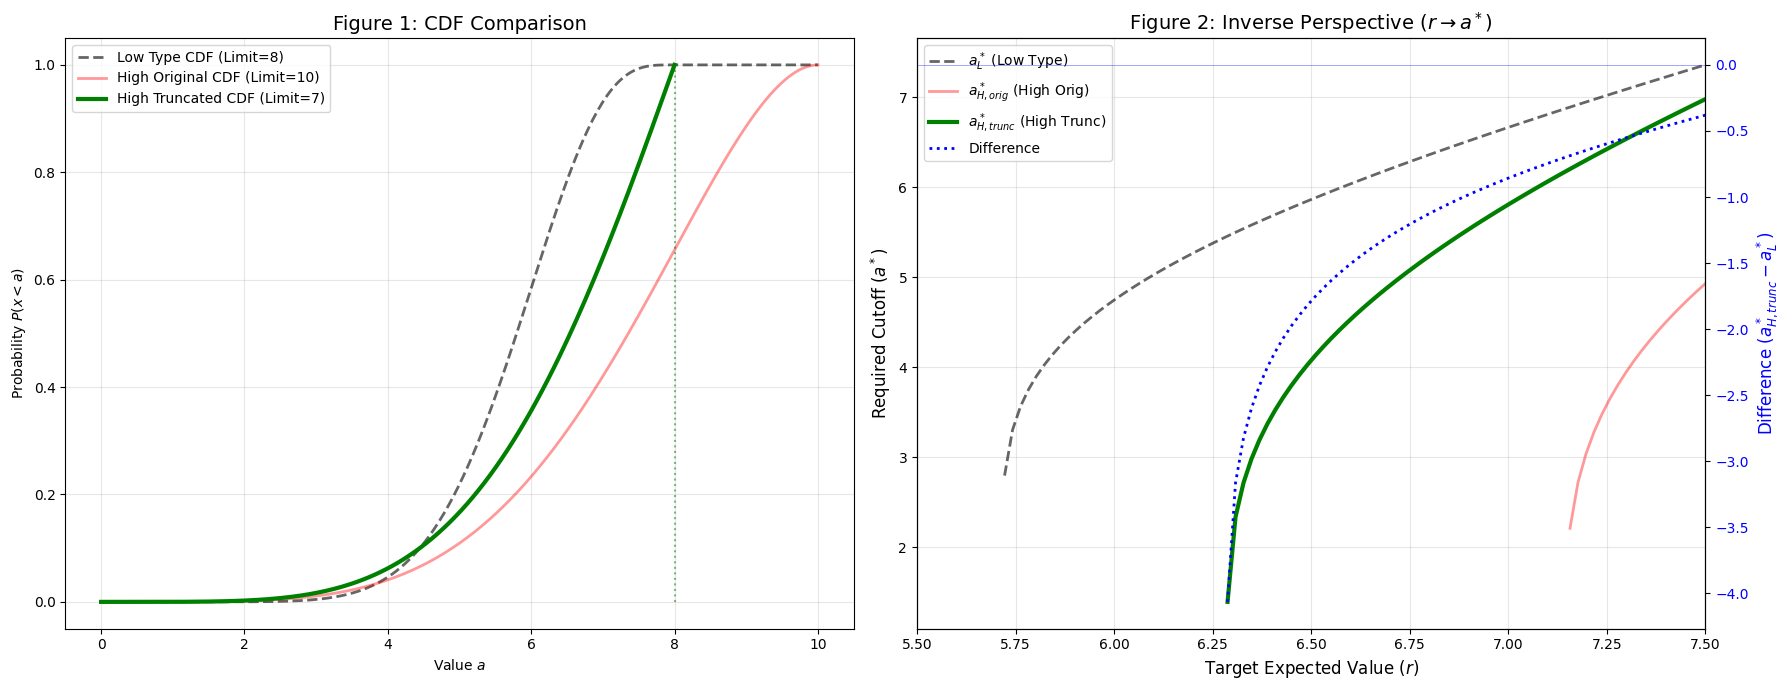

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.integrate import quad
from scipy.optimize import brentq

# ==========================================
# 1. 定义分布参数
# ==========================================

LIMIT_L = 8.0
LIMIT_H_ORIG = 10.0
LIMIT_H_TRUNC = 7.0

# --- L 分布 (Beta(2,2) * 8) ---
def cdf_l_func(x):
    if x < 0: return 0
    if x >= LIMIT_L: return 1
    return beta.cdf(x / LIMIT_L, 2, 5)

# --- H 原始分布 (Beta(5,2) * 10) ---
def cdf_h_orig_func(x):
    if x < 0: return 0
    if x >= LIMIT_H_ORIG: return 1
    return beta.cdf(x / LIMIT_H_ORIG, 5, 2)

# --- H 截断分布 (在 7.0 处截断并归一化) ---
# 计算归一化常数
norm_const = cdf_h_orig_func(LIMIT_H_TRUNC)

def cdf_h_trunc_func(x):
    if x < 0: return 0
    if x >= LIMIT_H_TRUNC: return 1
    val = cdf_h_orig_func(x) / norm_const
    return min(val, 1.0)

# ==========================================
# 2. 核心计算：正向 (a* -> r) 与 反向 (r -> a*)
# ==========================================

def get_mrl(a_star, cdf_func, limit):
    """
    正向计算: 给定门槛 a*, 计算条件期望 r
    """
    if a_star >= limit - 1e-4:
        return limit

    prob_survival = 1.0 - cdf_func(a_star)
    if prob_survival <= 1e-9: return limit

    # 积分 (1 - F(x)) dx
    integral_val, _ = quad(lambda x: 1.0 - cdf_func(x), a_star, limit)
    return a_star + integral_val / prob_survival

def get_cutoff_given_r(target_r, cdf_func, limit):
    """
    反向求解: 给定目标期望 r, 求解所需的门槛 a*
    即求解方程: MRL(a*) - r = 0
    """
    # 1. 检查可行性
    # 计算最低可能的期望 (当 a*=0 时)
    min_possible_r = get_mrl(0, cdf_func, limit)

    # 如果目标 r 比全局均值还低，或者比上限还高，则无解
    if target_r < min_possible_r or target_r >= limit:
        return np.nan

    # 2. 求解根
    def objective(a_star):
        return get_mrl(a_star, cdf_func, limit) - target_r

    try:
        # 在 [0, limit) 范围内搜索
        return brentq(objective, 0, limit - 1e-4)
    except ValueError:
        return np.nan

# ==========================================
# 3. 生成绘图数据
# ==========================================

# 设定 r 的扫描范围
# 我们从 5.5 开始扫描到 7.5 (覆盖解的区域)
r_values = np.linspace(5.5, 7.5, 100)

# 1. 计算 L 的 a*
a_vals_l = [get_cutoff_given_r(r, cdf_l_func, LIMIT_L) for r in r_values]

# 2. 计算 H (原始) 的 a*
a_vals_h_orig = [get_cutoff_given_r(r, cdf_h_orig_func, LIMIT_H_ORIG) for r in r_values]

# 3. 计算 H (截断) 的 a*
# 注意：当 r > 7.0 时，截断分布无法达到该期望，返回 NaN
a_vals_h_trunc = [get_cutoff_given_r(r, cdf_h_trunc_func, LIMIT_H_TRUNC) for r in r_values]

# 4. 计算差值 (H_trunc - L)
diff_vals = []
sol_r = None
sol_a = None

for i, r in enumerate(r_values):
    val_h = a_vals_h_trunc[i]
    val_l = a_vals_l[i]

    if np.isnan(val_h) or np.isnan(val_l):
        diff_vals.append(np.nan)
    else:
        diff = val_h - val_l
        diff_vals.append(diff)

        # 简单的线性插值找零点用于标注
        if i > 0 and not np.isnan(diff_vals[i-1]):
            if diff_vals[i-1] * diff < 0: # 符号改变
                sol_r = r
                sol_a = val_h # 近似解

# ==========================================
# 4. 绘图代码
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- 图 1: CDF 对比 ---
x_cdf = np.linspace(0, 10, 300)
x_cdf_trunc = np.linspace(0, LIMIT_H_TRUNC, 200)

ax1.plot(x_cdf, [cdf_l_func(x) for x in x_cdf], 'k--', lw=2, label='Low Type CDF (Limit=8)', alpha=0.6)
ax1.plot(x_cdf, [cdf_h_orig_func(x) for x in x_cdf], 'r-', lw=2, label='High Original CDF (Limit=10)', alpha=0.4)
ax1.plot(x_cdf_trunc, [cdf_h_trunc_func(x) for x in x_cdf_trunc], 'g-', lw=3, label='High Truncated CDF (Limit=7)')
ax1.vlines(LIMIT_H_TRUNC, 0, 1, colors='green', linestyles=':', alpha=0.5)

ax1.set_title("Figure 1: CDF Comparison", fontsize=14)
ax1.set_xlabel("Value $a$")
ax1.set_ylabel("Probability $P(x < a)$")
ax1.legend()
ax1.grid(True, alpha=0.3)


# --- 图 2: 反向视角 (r -> a*) ---

# 左轴：画 a* 曲线
ax2.set_xlabel("Target Expected Value ($r$)", fontsize=12)
ax2.set_ylabel("Required Cutoff ($a^*$)", fontsize=12)

# L 曲线
ln1 = ax2.plot(r_values, a_vals_l, 'k--', lw=2, label='$a^*_L$ (Low Type)', alpha=0.6)
# H 原始曲线
ln2 = ax2.plot(r_values, a_vals_h_orig, 'r-', lw=2, label='$a^*_{H,orig}$ (High Orig)', alpha=0.4)
# H 截断曲线
ln3 = ax2.plot(r_values, a_vals_h_trunc, 'g-', lw=3, label='$a^*_{H,trunc}$ (High Trunc)')

# 右轴：画差值曲线
ax2_right = ax2.twinx()
ax2_right.set_ylabel("Difference ($a^*_{H,trunc} - a^*_L$)", color='blue', fontsize=12)
ln4 = ax2_right.plot(r_values, diff_vals, color='blue', linestyle=':', lw=2, label='Difference')

# 添加零点参考线
ax2_right.axhline(0, color='blue', linewidth=0.5, alpha=0.5)
ax2_right.tick_params(axis='y', labelcolor='blue')

# 标注交点
if sol_r:
    # 在左轴标点
    ax2.scatter([sol_r], [sol_a], color='red', s=100, zorder=10, edgecolors='black')
    ax2.annotate(f'Solution:\nr={sol_r:.3f}\na*={sol_a:.3f}',
                 xy=(sol_r, sol_a), xytext=(sol_r-0.8, sol_a+1.0),
                 arrowprops=dict(facecolor='red', shrink=0.05))

    # 在右轴标零点
    ax2_right.scatter([sol_r], [0], color='blue', s=50, zorder=10)
    ax2_right.annotate('Diff = 0', xy=(sol_r, 0), xytext=(sol_r+0.2, -0.5), color='blue',
                       arrowprops=dict(arrowstyle="->", color='blue'))

# 合并图例
lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='upper left')

ax2.set_title("Figure 2: Inverse Perspective ($r \\rightarrow a^*$)", fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(5.5, 7.5) # 聚焦在解的区域

plt.tight_layout()
plt.show()

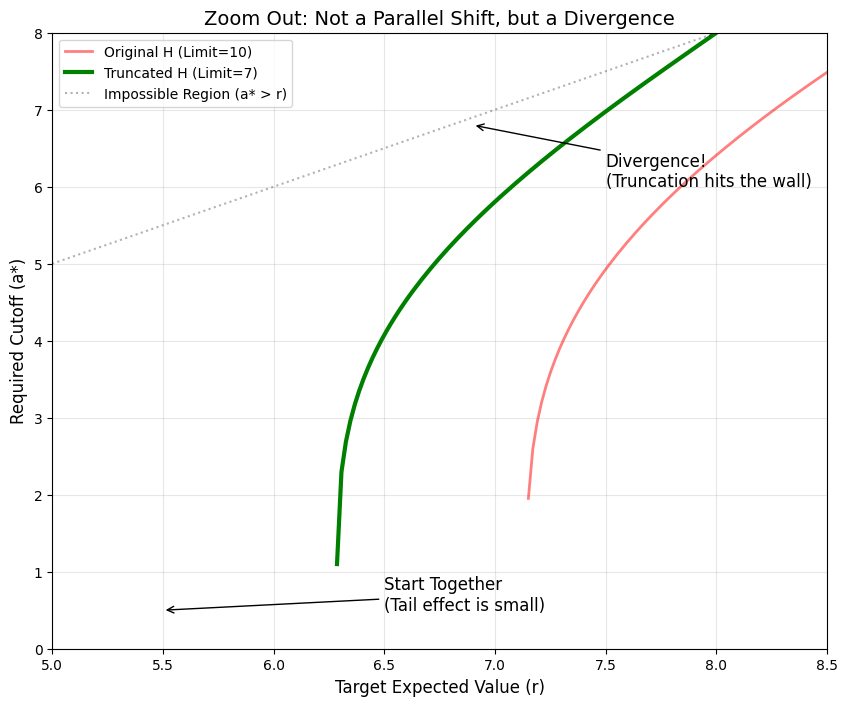

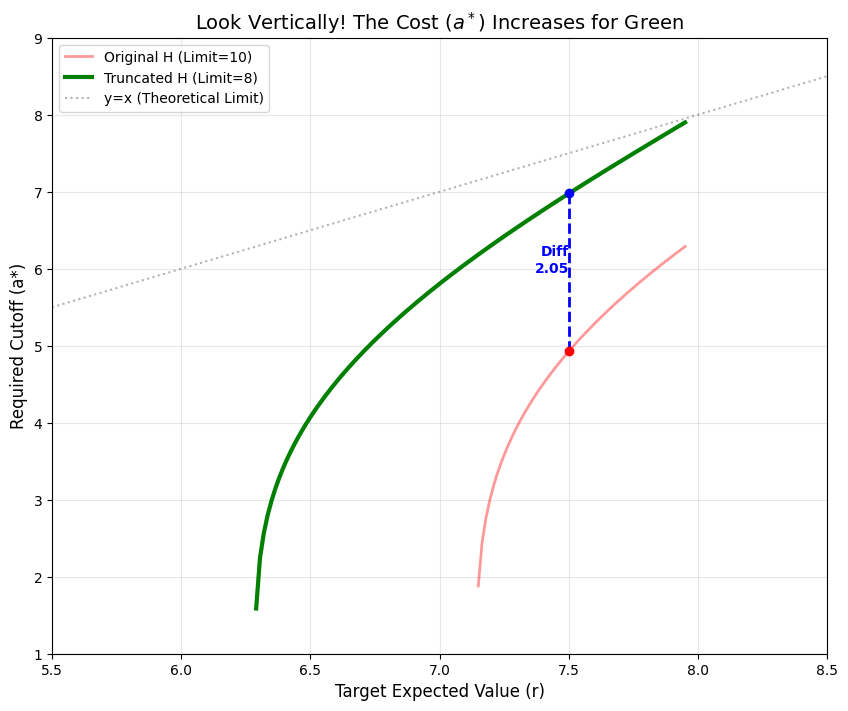

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.integrate import quad
from scipy.optimize import brentq

# ============================
# 参数设置 (你的设定)
# ============================
LIMIT_H_ORIG = 10.0
LIMIT_H_TRUNC = 8.0  # 你刚才观察的是截断在 8

# 定义分布
def cdf_h_orig_func(x):
    if x < 0: return 0
    if x >= LIMIT_H_ORIG: return 1
    return beta.cdf(x / LIMIT_H_ORIG, 5, 2)

norm_const = cdf_h_orig_func(LIMIT_H_TRUNC)
def cdf_h_trunc_func(x):
    if x < 0: return 0
    if x >= LIMIT_H_TRUNC: return 1
    val = cdf_h_orig_func(x) / norm_const
    return min(val, 1.0)

# 求解函数
def get_mrl(a_star, cdf_func, limit):
    if a_star >= limit - 1e-4: return limit
    prob = 1.0 - cdf_func(a_star)
    if prob <= 1e-9: return limit
    val, _ = quad(lambda x: 1.0 - cdf_func(x), a_star, limit)
    return a_star + val / prob

def get_cutoff(target_r, cdf_func, limit):
    min_r = get_mrl(0, cdf_func, limit)
    if target_r < min_r or target_r >= limit: return np.nan
    try:
        return brentq(lambda a: get_mrl(a, cdf_func, limit) - target_r, 0, limit-1e-3)
    except: return np.nan

# ============================
# 绘图数据
# ============================
r_values = np.linspace(5.0, 7.95, 200) # 画到 8 附近
a_orig = [get_cutoff(r, cdf_h_orig_func, LIMIT_H_ORIG) for r in r_values]
a_trunc = [get_cutoff(r, cdf_h_trunc_func, LIMIT_H_TRUNC) for r in r_values]

# ============================
# 可视化：垂直对比
# ============================
plt.figure(figsize=(10, 8))

# 1. 画主曲线
plt.plot(r_values, a_orig, 'r-', lw=2, label='Original H (Limit=10)', alpha=0.4)
plt.plot(r_values, a_trunc, 'g-', lw=3, label='Truncated H (Limit=8)')
plt.plot([5, 10], [5, 10], 'k:', alpha=0.3, label='y=x (Theoretical Limit)')

# 2. 关键：画垂直差距线 (Vertical Gap)
check_points = [6.0, 6.8, 7.5] # 检查这三个 r 点
for r_check in check_points:
    # 找对应的 a*
    try:
        y_orig = get_cutoff(r_check, cdf_h_orig_func, LIMIT_H_ORIG)
        y_trunc = get_cutoff(r_check, cdf_h_trunc_func, LIMIT_H_TRUNC)

        if not np.isnan(y_orig) and not np.isnan(y_trunc):
            # 画垂直虚线
            plt.vlines(r_check, y_orig, y_trunc, color='blue', linestyles='--', lw=2)
            # 标出差距数值
            diff = y_trunc - y_orig
            plt.text(r_check, (y_orig + y_trunc)/2, f'Diff\n{diff:.2f}',
                     color='blue', ha='right', fontweight='bold')
            # 画箭头
            plt.plot(r_check, y_trunc, 'bo')
            plt.plot(r_check, y_orig, 'ro')
    except:
        pass

plt.title('Look Vertically! The Cost ($a^*$) Increases for Green', fontsize=14)
plt.xlabel('Target Expected Value (r)', fontsize=12)
plt.ylabel('Required Cutoff (a*)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(5.5, 8.5)
plt.ylim(1.0, 9.0)

plt.show()

Equilibrium r: 7.0000
Sender l: a*=6.0000, Mass=2.0000
Sender h: a*=4.0000, Mass=6.0000


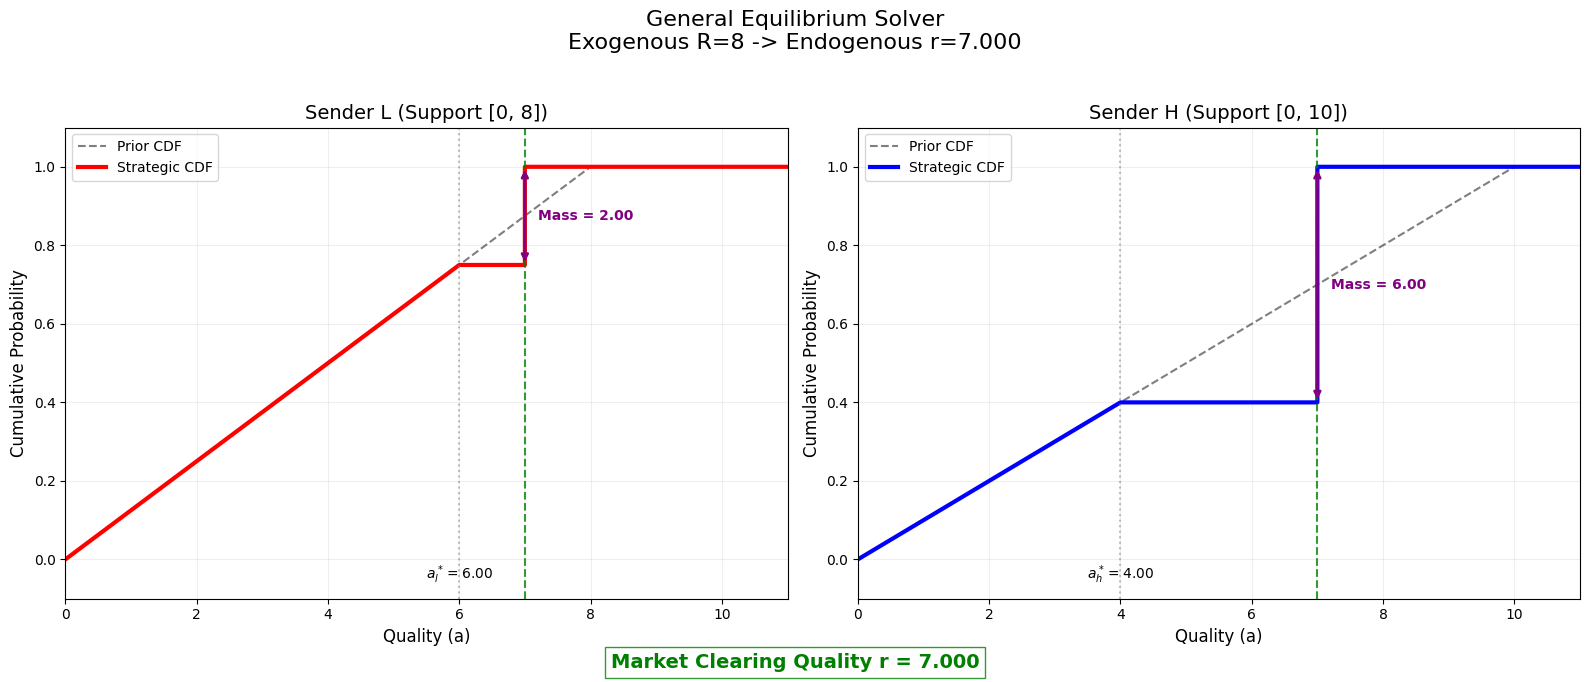

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

# ==========================================
# Part 1: General Numerical Solver Logic
# (Works for ANY continuous distribution)
# ==========================================

def get_mean_residual_life(a_star, cdf_func, limit):
    """
    Calculates E[a | a > a_star] numerically for ANY distribution.
    Formula: a* + Integral_{a*}^{limit} (1 - F(x)) dx / (1 - F(a*))
    """
    if a_star >= limit - 1e-5:
        return limit

    # 1. Calculate Survival Probability P(a > a*)
    survival_prob = 1.0 - cdf_func(a_star)

    # Avoid division by zero
    if survival_prob <= 1e-9:
        return limit

    # 2. Numerical Integration of Survival Function
    # This is more numerically stable than integrating x*pdf
    integral_val, _ = quad(lambda x: 1.0 - cdf_func(x), a_star, limit)

    return a_star + integral_val / survival_prob

def get_cutoff_from_target_r(target_r, cdf_func, limit):
    """
    Inverse function: Given target r, find required a* numerically.
    Solves MRL(a*) - r = 0
    """
    # 1. Check bounds
    min_possible_r = get_mean_residual_life(0, cdf_func, limit) # Global mean

    if target_r < min_possible_r:
        return 0.0 # Should not happen if R is feasible
    if target_r >= limit:
        return limit

    # 2. Root finding
    try:
        # We search a* in range [0, limit]
        return brentq(lambda a: get_mean_residual_life(a, cdf_func, limit) - target_r,
                      0, limit - 1e-4)
    except ValueError:
        return limit # Fallback

def find_equilibrium_r(R_supply, senders_list):
    """
    Finds the endogenous r that clears the market.
    R_supply: Exogenous Total Mass allowed
    senders_list: list of dicts {'cdf': func, 'limit': float, 'q': float}
    """

    # Define the Market Clearance Error function
    def market_excess_demand(test_r):
        total_mass_supplied = 0.0
        for sender in senders_list:
            # For this test_r, what cutoff a* does this sender need?
            a_star = get_cutoff_from_target_r(test_r, sender['cdf'], sender['limit'])
            # Mass = q * (1 - F(a*))
            mass = sender['q'] * (1.0 - sender['cdf'](a_star))
            total_mass_supplied += mass

        return total_mass_supplied - R_supply

    # Search range for r:
    # Min r: The weighted average of global means (rough lower bound)
    # Max r: The highest support limit
    max_limit = max(s['limit'] for s in senders_list)
    min_limit_r = min(get_mean_residual_life(0, s['cdf'], s['limit']) for s in senders_list)

    try:
        r_solution = brentq(market_excess_demand, min_limit_r, max_limit - 1e-3)
        return r_solution
    except ValueError:
        print("Error: Could not find equilibrium r. R might be too large or small.")
        return None

# ==========================================
# Part 2: Configuration (Example 1)
# ==========================================

# Define distributions (Linear/Uniform for this example, but can be anything)
LIMIT_L = 8.0
LIMIT_H = 10.0
Q_L = 8
Q_H = 10
R_EXOGENOUS = 8  # The exogenous constraint

# CDF Functions
def cdf_l_func(x):
    if x < 0: return 0.0
    if x >= LIMIT_L: return 1.0
    return x / LIMIT_L  # Linear

def cdf_h_func(x):
    if x < 0: return 0.0
    if x >= LIMIT_H: return 1.0
    return x / LIMIT_H  # Linear

# Package for the solver
senders_config = [
    {'label': 'l', 'cdf': cdf_l_func, 'limit': LIMIT_L, 'q': Q_L},
    {'label': 'h', 'cdf': cdf_h_func, 'limit': LIMIT_H, 'q': Q_H}
]

# ==========================================
# Part 3: Execution & Plotting
# ==========================================

# 1. Solve for Equilibrium r
r_star = find_equilibrium_r(R_EXOGENOUS, senders_config)

# 2. Back-calculate specific strategies for plotting
results = []
for sender in senders_config:
    a_star = get_cutoff_from_target_r(r_star, sender['cdf'], sender['limit'])
    mass = sender['q'] * (1.0 - sender['cdf'](a_star))
    prob_cutoff = sender['cdf'](a_star)
    results.append({
        'label': sender['label'],
        'limit': sender['limit'],
        'a_star': a_star,
        'mass': mass,
        'prob_cutoff': prob_cutoff
    })

# Print values to verify
print(f"Equilibrium r: {r_star:.4f}")
for res in results:
    print(f"Sender {res['label']}: a*={res['a_star']:.4f}, Mass={res['mass']:.4f}")

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_sender_strategy(ax, res_data, cdf_func):
    label = res_data['label']
    limit = res_data['limit']
    a_star = res_data['a_star']
    prob_cutoff = res_data['prob_cutoff']
    mass = res_data['mass']

    x_max = max(LIMIT_L, LIMIT_H) + 1

    # A. Draw Prior CDF
    x_vals = np.linspace(0, limit, 200)
    y_vals = [cdf_func(x) for x in x_vals]
    ax.plot(x_vals, y_vals, 'k--', linewidth=1.5, alpha=0.5, label='Prior CDF')

    # B. Draw Strategic CDF
    # Path: (0,0) -> (a*, F(a*)) -> (r, F(a*)) -> (r, 1) -> (end, 1)
    x_strat = [0, a_star, r_star, r_star, x_max]
    y_strat = [0, prob_cutoff, prob_cutoff, 1.0, 1.0]

    color = 'red' if label == 'l' else 'blue'
    ax.plot(x_strat, y_strat, color=color, linewidth=3, label='Strategic CDF')

    # C. Annotations (English Only)

    # Mass Arrow (Fixed annotate error)
    # The first argument must be the text (even if empty)
    ax.annotate(text='', xy=(r_star, prob_cutoff), xytext=(r_star, 1.0),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax.text(r_star + 0.2, (1.0 + prob_cutoff)/2, f'Mass = {mass:.2f}',
            color='purple', va='center', fontweight='bold')

    # a* line
    ax.axvline(a_star, color='gray', linestyle=':', alpha=0.5)
    ax.text(a_star, -0.05, f'$a^*_{label}={a_star:.2f}$',
            color='black', ha='center', fontweight='bold')

    # r line
    ax.axvline(r_star, color='green', linestyle='--', alpha=0.8)

    # Limits
    ax.set_title(f'Sender {label.upper()} (Support [0, {int(limit)}])', fontsize=14)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0, x_max)
    ax.set_xlabel('Quality (a)', fontsize=12)
    ax.set_ylabel('Cumulative Probability', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)

# Plot both
plot_sender_strategy(axes[0], results[0], cdf_l_func)
plot_sender_strategy(axes[1], results[1], cdf_h_func)

# Global Title
plt.suptitle(f'General Equilibrium Solver\nExogenous R={R_EXOGENOUS} -> Endogenous r={r_star:.3f}',
             fontsize=16, y=0.98)

# Center text
fig.text(0.5, 0.04, f'Market Clearing Quality r = {r_star:.3f}',
         ha='center', color='green', fontsize=14, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='green'))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

开始暴力搜索满足条件的分布参数...
条件 1: 在某个 r 下，a*_L < a*_H (Flip)
条件 2: 在另一个 r 下，a*_L > a*_H (Normal)
条件 3: 必须是 Interior Solution (非 0 非 Limit)

[成功] 在第 828 次尝试找到完美参数！
Sender L Beta(3.84, 1.01)
Sender H Beta(1.10, 1.20)

--- Scenario A: Loose Market (High R) ---
Total R: 14.30 (Equilibrium r = 6.431)
L: a*=3.04, Mass=7.80
H: a*=3.35, Mass=6.50

--- Scenario B: Tight Market (Low R) ---
Total R: 4.21 (Equilibrium r = 7.900)
L: a*=7.80, Mass=0.72
H: a*=6.12, Mass=3.49


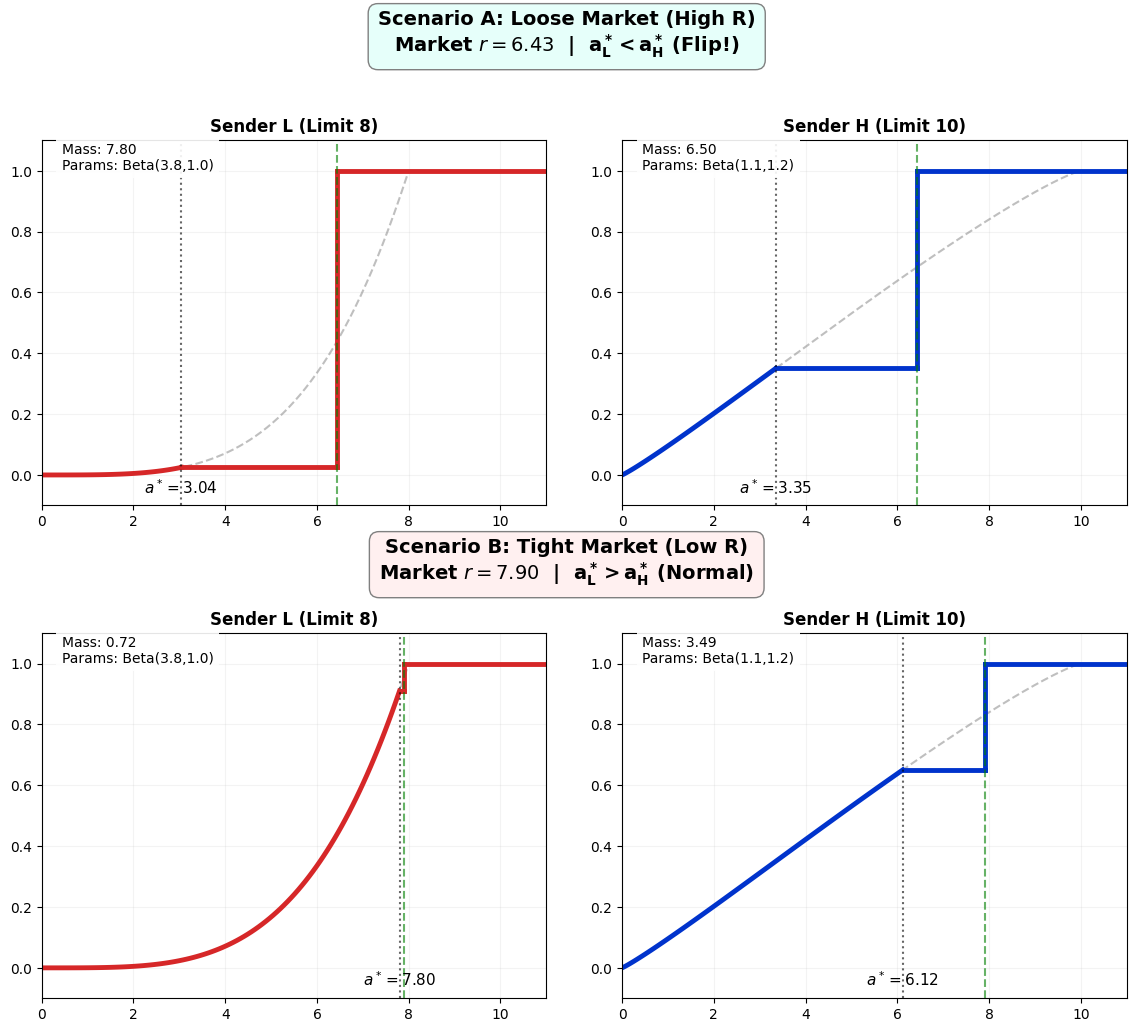

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.stats import beta
import time

# ==========================================
# 1. 核心数学逻辑 (Solver)
# ==========================================

def get_mean_residual_life(a_star, cdf_func, limit):
    """ 计算 E[a | a > a_star] """
    if a_star >= limit - 1e-3: return limit
    prob_survival = 1.0 - cdf_func(a_star)
    if prob_survival < 1e-6: return limit
    try:
        integral_val, _ = quad(lambda x: 1.0 - cdf_func(x), a_star, limit, limit=50)
        return a_star + integral_val / prob_survival
    except:
        return limit

def get_cutoff_from_target_r(target_r, cdf_func, limit):
    """ 给定 r，反解 a* """
    min_r = get_mean_residual_life(0, cdf_func, limit)
    if target_r <= min_r + 1e-4: return 0.0
    if target_r >= limit - 1e-4: return limit
    try:
        return brentq(lambda a: get_mean_residual_life(a, cdf_func, limit) - target_r, 0, limit - 1e-3)
    except ValueError:
        return limit

def calculate_R(target_r, senders):
    """ 给定 r，计算总供给 R """
    total_mass = 0
    for s in senders:
        a = get_cutoff_from_target_r(target_r, s['cdf'], s['limit'])
        total_mass += s['q'] * (1.0 - s['cdf'](a))
    return total_mass

# ==========================================
# 2. 暴力搜索引擎 (The Search Engine)
# ==========================================

def find_perfect_parameters():
    print("开始暴力搜索满足条件的分布参数...")
    print("条件 1: 在某个 r 下，a*_L < a*_H (Flip)")
    print("条件 2: 在另一个 r 下，a*_L > a*_H (Normal)")
    print("条件 3: 必须是 Interior Solution (非 0 非 Limit)")

    LIMIT_L, LIMIT_H = 8.0, 10.0
    Q_L, Q_H = 8, 10

    attempt = 0
    while True:
        attempt += 1

        # === 1. 随机生成 Sender L 的形状 (倾向于“好”分布) ===
        # Alpha 大 (3~6), Beta 小 (1~2) -> 均值高，左尾巴薄
        alpha_l = np.random.uniform(3.5, 6.0)
        beta_l = np.random.uniform(1.0, 1.5)

        # === 2. 随机生成 Sender H 的形状 (倾向于“平庸”分布) ===
        # Uniform 或接近 Uniform -> 均值低，方差大
        alpha_h = np.random.uniform(1.0, 1.2)
        beta_h = np.random.uniform(1.0, 1.2)

        # 定义临时函数
        def cdf_l(x): return beta.cdf(x/LIMIT_L, alpha_l, beta_l) if 0 <= x < LIMIT_L else (1.0 if x >= LIMIT_L else 0.0)
        def cdf_h(x): return beta.cdf(x/LIMIT_H, alpha_h, beta_h) if 0 <= x < LIMIT_H else (1.0 if x >= LIMIT_H else 0.0)

        temp_senders = [
            {'label': 'L', 'cdf': cdf_l, 'limit': LIMIT_L, 'q': Q_L},
            {'label': 'H', 'cdf': cdf_h, 'limit': LIMIT_H, 'q': Q_H}
        ]

        # === 3. 扫描这个参数组合下的 r 空间 ===
        # 确定扫描范围
        min_r = max([get_mean_residual_life(0, s['cdf'], s['limit']) for s in temp_senders]) + 0.1
        max_r = 7.9 # 不要太接近 8，否则 L 很容易崩

        r_grid = np.linspace(min_r, max_r, 50)

        found_flip = None
        found_normal = None

        for r in r_grid:
            a_L = get_cutoff_from_target_r(r, cdf_l, LIMIT_L)
            a_H = get_cutoff_from_target_r(r, cdf_h, LIMIT_H)

            # 严格检查 Interior Solution (0.2 < a* < limit - 0.5)
            # 我们希望肉眼能明显看出来，所以阈值设得严一点
            is_interior = (a_L > 0.2 and a_L < LIMIT_L - 0.2) and \
                          (a_H > 0.2 and a_H < LIMIT_H - 0.2)

            if is_interior:
                diff = a_L - a_H
                # 寻找 Normal Case (a_L 显著大于 a_H)
                if diff > 0.5:
                    if found_normal is None or diff > (found_normal['a_L'] - found_normal['a_H']):
                        found_normal = {'r': r, 'a_L': a_L, 'a_H': a_H}

                # 寻找 Flip Case (a_L 显著小于 a_H)
                if diff < -0.3:
                    if found_flip is None or diff < (found_flip['a_L'] - found_flip['a_H']):
                        found_flip = {'r': r, 'a_L': a_L, 'a_H': a_H}

        # === 4. 如果找到了完美的一对，停止循环 ===
        if found_flip and found_normal:
            print(f"\n[成功] 在第 {attempt} 次尝试找到完美参数！")
            print(f"Sender L Beta({alpha_l:.2f}, {beta_l:.2f})")
            print(f"Sender H Beta({alpha_h:.2f}, {beta_h:.2f})")

            # 补全 Sender Config 用于返回
            final_senders = [
                {'label': 'L', 'cdf': cdf_l, 'limit': LIMIT_L, 'q': Q_L, 'color': '#D62728', 'params': f'Beta({alpha_l:.1f},{beta_l:.1f})'},
                {'label': 'H', 'cdf': cdf_h, 'limit': LIMIT_H, 'q': Q_H, 'color': '#0033CC', 'params': f'Beta({alpha_h:.1f},{beta_h:.1f})'}
            ]
            return final_senders, found_flip, found_normal

# ==========================================
# 3. 执行搜索并绘图
# ==========================================

# 1. 运行搜索
senders_config, flip_data, normal_data = find_perfect_parameters()

# 2. 准备绘图数据
scenarios = [
    {
        "name": "Scenario A: Loose Market (High R)",
        "r": flip_data['r'],
        "R": calculate_R(flip_data['r'], senders_config),
        "note": r"$\mathbf{a^*_L < a^*_H}$ (Flip!)",
        "bg": "#e6fffa"
    },
    {
        "name": "Scenario B: Tight Market (Low R)",
        "r": normal_data['r'],
        "R": calculate_R(normal_data['r'], senders_config),
        "note": r"$\mathbf{a^*_L > a^*_H}$ (Normal)",
        "bg": "#fff0f0"
    }
]

# 3. 开始绘图
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for i, scen in enumerate(scenarios):
    r_val = scen['r']

    # 重新计算一次由 r 导出的 cutoff，确保绘图精准
    res_list = []
    for s in senders_config:
        a_star = get_cutoff_from_target_r(r_val, s['cdf'], s['limit'])
        mass = s['q'] * (1.0 - s['cdf'](a_star))
        res_list.append({'a_star': a_star, 'mass': mass, 'prob': s['cdf'](a_star), **s})

    res_L, res_H = res_list[0], res_list[1]

    # 控制台打印
    print(f"\n--- {scen['name']} ---")
    print(f"Total R: {scen['R']:.2f} (Equilibrium r = {r_val:.3f})")
    print(f"L: a*={res_L['a_star']:.2f}, Mass={res_L['mass']:.2f}")
    print(f"H: a*={res_H['a_star']:.2f}, Mass={res_H['mass']:.2f}")

    # 绘图 Loop
    for j, res in enumerate(res_list):
        ax = axes[i, j]
        limit = res['limit']
        a_s = res['a_star']
        prob = res['prob']
        color = res['color']

        # 1. Prior CDF
        x_p = np.linspace(0, limit, 200)
        ax.plot(x_p, [res['cdf'](x) for x in x_p], 'gray', ls='--', alpha=0.5, label='Prior')

        # 2. Strategic CDF
        # Curve
        x_1 = np.linspace(0, a_s, 100)
        ax.plot(x_1, [res['cdf'](x) for x in x_1], color=color, lw=3.5)
        # Gap
        ax.plot([a_s, r_val], [prob, prob], color=color, lw=3.5)
        # Jump
        ax.plot([r_val, r_val], [prob, 1.0], color=color, lw=3.5)
        # Flat
        ax.plot([r_val, 11], [1.0, 1.0], color=color, lw=3.5)

        # 3. 标注
        ax.axvline(a_s, color='black', ls=':', alpha=0.6)
        ax.text(a_s, -0.06, f"$a^*={a_s:.2f}$", color='black', ha='center', fontweight='bold', fontsize=11)

        ax.axvline(r_val, color='green', ls='--', alpha=0.6)

        # 信息框
        info = f"Mass: {res['mass']:.2f}\nParams: {res['params']}"
        ax.text(0.04, 0.92, info, transform=ax.transAxes,
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'), fontsize=10)

        ax.set_ylim(-0.1, 1.1)
        ax.set_xlim(0, 11)
        ax.grid(True, alpha=0.15)
        ax.set_title(f"Sender {res['label']} (Limit {int(limit)})", fontweight='bold')

    # 行标题
    fig.text(0.5, 0.94 - i*0.48, f"{scen['name']}\nMarket $r={r_val:.2f}$  |  {scen['note']}",
             ha='center', fontsize=14, fontweight='bold',
             bbox=dict(facecolor=scen['bg'], edgecolor='gray', boxstyle='round,pad=0.5'))

plt.subplots_adjust(top=0.86, bottom=0.08, hspace=0.35, wspace=0.15)
plt.show()

          MODEL INPUTS
Advantaged (h)  : q_h = 2.0  , bar_a_h = 10.0 
Disadvantaged(l): q_l = 8.0  , bar_a_l = 8.0  
Market & Prize  : R   = 8.0  , r2      = 6.0  
Prize Scheme    : A2  = 1.7500, A1      = 1.0  
Target MB(A2/A1): 1.7500

=== Base Game ===
a_h: 0.002, a_l: 3.105, r1: 4.833
Q_h: 2.000, Q_l: 3.966
MC_h: 0.2047, MC_l: 0.1032
U_h: 2.000, U_l: 3.966

=== Piece-Wise Equilibrium ===
W_h: 2.000 (Max: 2.000), W_l: 0.945 (Max: 0.945)
a_h: 0.000, a_l: 1.944, r1: 3.455
Q_h: 0.000, Q_l: 5.055
MC_h: 0.7367, MC_l: 0.0000  <-- (Target MB = 1.7500)
U_h: 3.500, U_l: 0.839

=== Effect of Prize Scheme (r2=6.0, A2=1.75) ===
1. Cutoff Gap (a_h - a_l):
   Base: -3.103  ->  Eq: -1.944  |  Change: +1.158
2. Mismatch (|a_h - a_l|):
   Base: 3.103   ->  Eq: 1.944   |  Change: -1.158 (Reduced! )
3. Utility Difference (U_h - U_l):
   Base: -1.966  ->  Eq: +2.661  |  Change: +4.628 (Inequality Worsened)


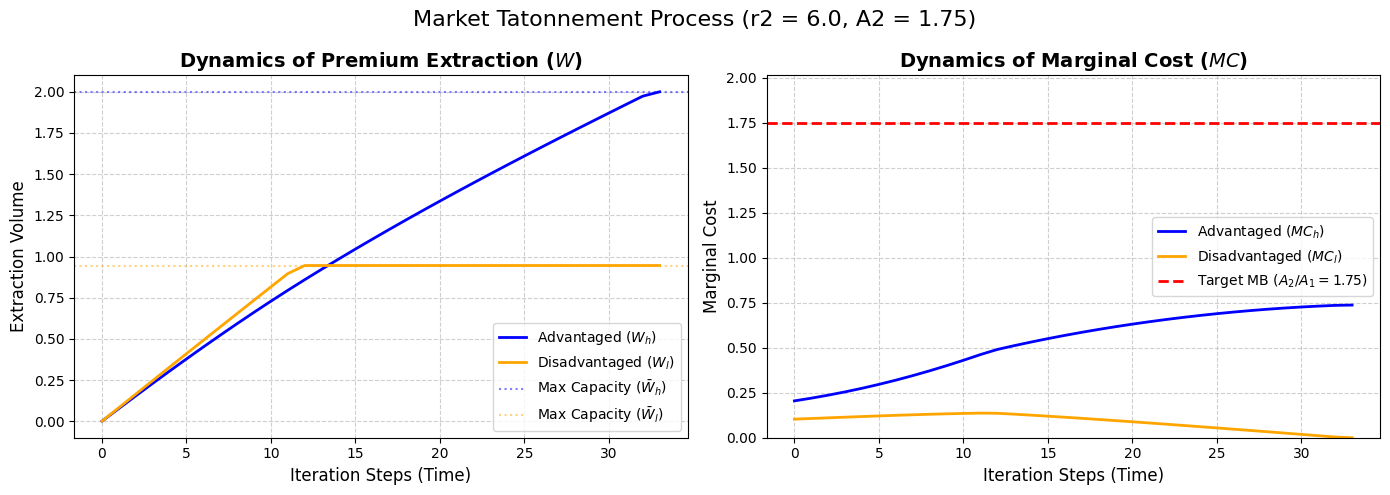

In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root, least_squares
import matplotlib.pyplot as plt
import warnings

# 忽略积分精度警告以保持控制台干净
warnings.filterwarnings("ignore")

def simulate_market_dynamics(q_h, pdf_h, bar_a_h,
                             q_l, pdf_l, bar_a_l,
                             R, r2, A2, A1=1.0,
                             lr=0.05, tol=1e-6, max_iter=20000):

    # 定义实际的密度函数 (f(x) = q * pdf(x))
    def f_h(x): return q_h * pdf_h(x) if 0 <= x <= bar_a_h else 0.0
    def f_l(x): return q_l * pdf_l(x) if 0 <= x <= bar_a_l else 0.0

    # 预定义生存函数与期望积分 (确保传入的是标量 float)
    def S_h(a): return quad(f_h, float(a), bar_a_h)[0]
    def S_l(a): return quad(f_l, float(a), bar_a_l)[0]
    def int_xf_h(a): return quad(lambda x: x * f_h(x), float(a), bar_a_h)[0]
    def int_xf_l(a): return quad(lambda x: x * f_l(x), float(a), bar_a_l)[0]

    # 寻找 Premium 池的物理上限 W_bar_i
    def find_W_bar(S_func, int_xf_func, bar_a):
        # 寻找边界 a2 使得条件期望等于 r2
        def obj(a):
            # SciPy 传入的是 array，我们需要提取第一个元素作为标量
            a_val = a[0] if isinstance(a, np.ndarray) else a
            s = S_func(a_val)
            if s <= 0: return r2 - bar_a
            return (int_xf_func(a_val) / s) - r2
        res = root(obj, [bar_a - 0.1])
        a2_star = float(res.x[0])
        return S_func(a2_star) if a2_star < bar_a else 0.0

    W_bar_h = find_W_bar(S_h, int_xf_h, bar_a_h)
    W_bar_l = find_W_bar(S_l, int_xf_l, bar_a_l)

    # 核心：给定 (W_h, W_l)，求解子博弈的 (a_h, a_l, r1)
    def solve_subgame(W_h, W_l, init_guess=[5.0, 5.0, 7.0]):
        def equations(vars):
            # 解包并强制转换为标量
            a_h, a_l, r1 = float(vars[0]), float(vars[1]), float(vars[2])

            eq1 = int_xf_h(a_h) - r1 * S_h(a_h) - (r2 - r1) * W_h
            eq2 = int_xf_l(a_l) - r1 * S_l(a_l) - (r2 - r1) * W_l
            eq3 = S_h(a_h) + S_l(a_l) - R
            return [eq1, eq2, eq3]

        # 定义物理边界：a_h 在 [0, bar_a_h]，a_l 在 [0, bar_a_l]，r1 在合理区间内
        upper_r1 = max(bar_a_h, bar_a_l, r2)
        bounds = ([0.0, 0.0, 0.0], [bar_a_h, bar_a_l, upper_r1])

        # 使用原生支持边界的 least_squares 替代 root
        res = least_squares(equations, init_guess, bounds=bounds, xtol=1e-8, ftol=1e-8)

        return float(res.x[0]), float(res.x[1]), float(res.x[2])

    # ==============================
    # 🚨 核心修改点：使用代数重构后的全局稳定 MC 公式
    # ==============================
    def calc_MC(a_h, a_l, r1, W_h, W_l):
        # 确保由于精度误差导致的极小负数被截断为 0
        Q_h = max(0.0, S_h(a_h) - W_h)
        Q_l = max(0.0, S_l(a_l) - W_l)

        # Sender h 的边际成本
        denom_h = Q_l * (r1 - a_h) + Q_h * (r1 - a_l)
        MC_h = (r2 - r1) * Q_l / denom_h if denom_h > 1e-12 else 0.0

        # Sender l 的边际成本
        denom_l = Q_h * (r1 - a_l) + Q_l * (r1 - a_h)
        MC_l = (r2 - r1) * Q_h / denom_l if denom_l > 1e-12 else 0.0

        return MC_h, MC_l

    # ==============================
    # 1. 求解 Base Game (无机制)
    # ==============================
    a_h_0, a_l_0, r1_0 = solve_subgame(0.0, 0.0)
    Q_h_0, Q_l_0 = S_h(a_h_0), S_l(a_l_0)
    MC_h_0, MC_l_0 = calc_MC(a_h_0, a_l_0, r1_0, 0.0, 0.0)

    base_results = {
        "W_h": 0.0, "W_l": 0.0,
        "Q_h": Q_h_0, "Q_l": Q_l_0,
        "a_h": a_h_0, "a_l": a_l_0, "r1": r1_0,
        "U_h": A1 * Q_h_0, "U_l": A1 * Q_l_0,
        "MC_h": MC_h_0, "MC_l": MC_l_0
    }

    # ==============================
    # 2. 模拟动态博弈直至收敛 (记录轨迹)
    # ==============================
    W_h, W_l = 0.0, 0.0
    last_guess = [a_h_0, a_l_0, r1_0]

    # 用于画图的历史记录列表
    history_MC_h, history_MC_l = [], []
    history_W_h, history_W_l = [], []

    for step in range(max_iter):
        a_h, a_l, r1 = solve_subgame(W_h, W_l, init_guess=last_guess)
        last_guess = [a_h, a_l, r1] # 传递给下一步加速收敛
        MC_h, MC_l = calc_MC(a_h, a_l, r1, W_h, W_l)

        # 记录当前时间步的系统状态
        history_MC_h.append(MC_h)
        history_MC_l.append(MC_l)
        history_W_h.append(W_h)
        history_W_l.append(W_l)

        # 梯度：MB - MC
        dW_h = A2/A1 - MC_h
        dW_l = A2/A1 - MC_l

        # 截断更新（不能小于0，不能超过物理上限）
        new_W_h = np.clip(W_h + lr * dW_h, 0.0, float(W_bar_h))
        new_W_l = np.clip(W_l + lr * dW_l, 0.0, float(W_bar_l))

        if abs(new_W_h - W_h) < tol and abs(new_W_l - W_l) < tol:
            W_h, W_l = new_W_h, new_W_l
            break
        W_h, W_l = new_W_h, new_W_l

    # ==============================
    # 3. 提取最终均衡统计量
    # ==============================
    a_h_star, a_l_star, r1_star = solve_subgame(W_h, W_l, init_guess=last_guess)
    Q_h_star = S_h(a_h_star) - W_h
    Q_l_star = S_l(a_l_star) - W_l

    eq_results = {
        "W_h": W_h, "W_l": W_l,
        "Q_h": Q_h_star, "Q_l": Q_l_star,
        "a_h": a_h_star, "a_l": a_l_star, "r1": r1_star,
        "U_h": A2 * W_h + A1 * Q_h_star/q_h,
        "U_l": (A2 * W_l + A1 * Q_l_star)/q_l,
        "MC_h_final": MC_h, "MC_l_final": MC_l,
        # 返回轨迹以供绘图
        "history_MC_h": history_MC_h,
        "history_MC_l": history_MC_l,
        "history_W_h": history_W_h,
        "history_W_l": history_W_l,
        "W_bar_h": W_bar_h,
        "W_bar_l": W_bar_l
    }

    return base_results, eq_results


# ==========================================
# 分析与绘图逻辑 (封装起来，保证干净不污染底部输入区)
# ==========================================
def run_example_analysis(q_h_val, bar_a_h_val, q_l_val, bar_a_l_val,
                         R_val, r2_val, target_A2, target_A1, pdf_h, pdf_l):
    MB = target_A2 / target_A1

    # 0. 打印输入参数 (Inputs)
    print("========================================")
    print("          MODEL INPUTS")
    print("========================================")
    print(f"Advantaged (h)  : q_h = {q_h_val:<5.1f}, bar_a_h = {bar_a_h_val:<5.1f}")
    print(f"Disadvantaged(l): q_l = {q_l_val:<5.1f}, bar_a_l = {bar_a_l_val:<5.1f}")
    print(f"Market & Prize  : R   = {R_val:<5.1f}, r2      = {r2_val:<5.1f}")
    print(f"Prize Scheme    : A2  = {target_A2:<5.4f}, A1      = {target_A1:<5.1f}")
    print(f"Target MB(A2/A1): {MB:.4f}")
    print("========================================\n")

    # 运行模拟
    base, eq = simulate_market_dynamics(
        q_h=q_h_val, pdf_h=pdf_h, bar_a_h=bar_a_h_val,
        q_l=q_l_val, pdf_l=pdf_l, bar_a_l=bar_a_l_val,
        R=R_val, r2=r2_val, A2=target_A2, A1=target_A1
    )

    # 打印 Base Game 和 Eq
    print("=== Base Game ===")
    print(f"a_h: {base['a_h']:.3f}, a_l: {base['a_l']:.3f}, r1: {base['r1']:.3f}")
    print(f"Q_h: {base['Q_h']:.3f}, Q_l: {base['Q_l']:.3f}")
    print(f"MC_h: {base['MC_h']:.4f}, MC_l: {base['MC_l']:.4f}")
    print(f"U_h: {base['U_h']:.3f}, U_l: {base['U_l']:.3f}\n")

    print("=== Piece-Wise Equilibrium ===")
    print(f"W_h: {eq['W_h']:.3f} (Max: {eq['W_bar_h']:.3f}), W_l: {eq['W_l']:.3f} (Max: {eq['W_bar_l']:.3f})")
    print(f"a_h: {eq['a_h']:.3f}, a_l: {eq['a_l']:.3f}, r1: {eq['r1']:.3f}")
    print(f"Q_h: {eq['Q_h']:.3f}, Q_l: {eq['Q_l']:.3f}")
    print(f"MC_h: {eq['MC_h_final']:.4f}, MC_l: {eq['MC_l_final']:.4f}  <-- (Target MB = {MB:.4f})")
    print(f"U_h: {eq['U_h']:.3f}, U_l: {eq['U_l']:.3f}\n")

    # 分析 Effect of Prize Scheme
    gap_base = base['a_h'] - base['a_l']
    gap_eq = eq['a_h'] - eq['a_l']
    gap_change = gap_eq - gap_base

    mis_base = abs(gap_base)
    mis_eq = abs(gap_eq)
    mis_change = mis_eq - mis_base

    u_diff_base = base['U_h'] - base['U_l']
    u_diff_eq = eq['U_h'] - eq['U_l']
    u_diff_change = u_diff_eq - u_diff_base

    print(f"=== Effect of Prize Scheme (r2={r2_val}, A2={target_A2}) ===")
    print("1. Cutoff Gap (a_h - a_l):")
    print(f"   Base: {gap_base:+.3f}  ->  Eq: {gap_eq:+.3f}  |  Change: {gap_change:+.3f}")
    print("2. Mismatch (|a_h - a_l|):")
    mis_tag = "Reduced! " if mis_change < 0 else "Worsened " if mis_change > 0 else "Unchanged"
    print(f"   Base: {mis_base:.3f}   ->  Eq: {mis_eq:.3f}   |  Change: {mis_change:+.3f} ({mis_tag})")
    print("3. Utility Difference (U_h - U_l):")
    u_tag = "Inequality Reduced!" if u_diff_change < 0 else "Inequality Worsened"
    print(f"   Base: {u_diff_base:+.3f}  ->  Eq: {u_diff_eq:+.3f}  |  Change: {u_diff_change:+.3f} ({u_tag})")

    # 绘制动态轨迹图 (Dynamics Plot)
    steps = np.arange(len(eq["history_MC_h"]))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 图1: W_h 和 W_l 的动态变化
    axes[0].plot(steps, eq["history_W_h"], label=r'Advantaged ($W_h$)', color='blue', linewidth=2)
    axes[0].plot(steps, eq["history_W_l"], label=r'Disadvantaged ($W_l$)', color='orange', linewidth=2)
    axes[0].axhline(y=eq["W_bar_h"], color='blue', linestyle=':', alpha=0.5, label=r'Max Capacity ($\bar{W}_h$)')
    axes[0].axhline(y=eq["W_bar_l"], color='orange', linestyle=':', alpha=0.5, label=r'Max Capacity ($\bar{W}_l$)')

    axes[0].set_title('Dynamics of Premium Extraction ($W$)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Iteration Steps (Time)', fontsize=12)
    axes[0].set_ylabel('Extraction Volume', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # 图2: MC_h 和 MC_l 的动态变化 (此时已确保公式稳定，不存在无穷大了)
    axes[1].plot(steps, eq["history_MC_h"], label=r'Advantaged ($MC_h$)', color='blue', linewidth=2)
    axes[1].plot(steps, eq["history_MC_l"], label=r'Disadvantaged ($MC_l$)', color='orange', linewidth=2)
    axes[1].axhline(y=MB, color='red', linestyle='dashed', linewidth=2, label=f'Target MB ($A_2/A_1 = {MB:.2f}$)')

    axes[1].set_title('Dynamics of Marginal Cost ($MC$)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Iteration Steps (Time)', fontsize=12)
    axes[1].set_ylabel('Marginal Cost', fontsize=12)

    max_y = max(max(eq["history_MC_h"] + [0]), max(eq["history_MC_l"] + [0]), MB) * 1.15
    axes[1].set_ylim(0, max_y)
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.suptitle(f"Market Tatonnement Process (r2 = {r2_val}, A2 = {target_A2})", fontsize=16)
    plt.tight_layout()
    plt.show()


# =========================================================================
# ⬇️ ⬇️ ⬇️  你可以在这里随意修改所有的输入参数和探索范围！  ⬇️ ⬇️ ⬇️
# =========================================================================
if __name__ == "__main__":

    # 1. 密度函数定义 (Beta 分布)
    # h方: Beta(3, 2) 缩放到 [0, 10]，质量更集中在高分段
    # l方: Beta(2, 3) 缩放到 [0, 8]，质量更集中在低分段
    from scipy.stats import beta

    def pdf_h_input(x):
        # 将原本定义在 [0,1] 的 Beta 映射到 [0, 10]
        return beta.pdf(x / 10.0, 3, 2) / 10.0

    def pdf_l_input(x):
        # 将原本定义在 [0,1] 的 Beta 映射到 [0, 8]
        return beta.pdf(x / 8.0, 2, 3) / 8.0

    # 2. 你的输入参数 (包含你尝试的 Boutique 少数派场景)
    q_h_val = 2.0          # 优势方总产量 (少数派)
    bar_a_h_val = 10.0     # 优势方质量上限

    q_l_val = 8.0          # 劣势方总产量 (多数派)
    bar_a_l_val = 8.0      # 劣势方质量上限

    R_val = 8.0            # 市场总接收量
    r2_val = 6.0           # Premium 质量要求

    target_A2 = 1.75       # 额外奖金
    target_A1 = 1.0        # 基础奖金

    # =========================================================================
    # ⬆️ ⬆️ ⬆️  修改完毕后直接运行即可  ⬆️ ⬆️ ⬆️
    # =========================================================================

    run_example_analysis(
        q_h_val=q_h_val, bar_a_h_val=bar_a_h_val,
        q_l_val=q_l_val, bar_a_l_val=bar_a_l_val,
        R_val=R_val, r2_val=r2_val,
        target_A2=target_A2, target_A1=target_A1,
        pdf_h=pdf_h_input, pdf_l=pdf_l_input
    )

开始计算 20x20 = 400 个网格点，请稍候...
进度: 1/20 行计算完成
进度: 2/20 行计算完成
进度: 3/20 行计算完成
进度: 4/20 行计算完成
进度: 5/20 行计算完成
进度: 6/20 行计算完成
进度: 7/20 行计算完成
进度: 8/20 行计算完成
进度: 9/20 行计算完成
进度: 10/20 行计算完成
进度: 11/20 行计算完成
进度: 12/20 行计算完成
进度: 13/20 行计算完成
进度: 14/20 行计算完成
进度: 15/20 行计算完成
进度: 16/20 行计算完成
进度: 17/20 行计算完成
进度: 18/20 行计算完成
进度: 19/20 行计算完成
进度: 20/20 行计算完成

逻辑验证 1: '效率提升'与'公平改善'的区域重合度为 34.0%

        OVERSHOOTING 逻辑检测
 检测到 Overshooting 越界点：
  -> Mismatch 恶化网格数: 0
  -> Utility Diff 恶化网格数: 275
结论: 奖金 A2 过高导致提取过度，红区已在图中标出！



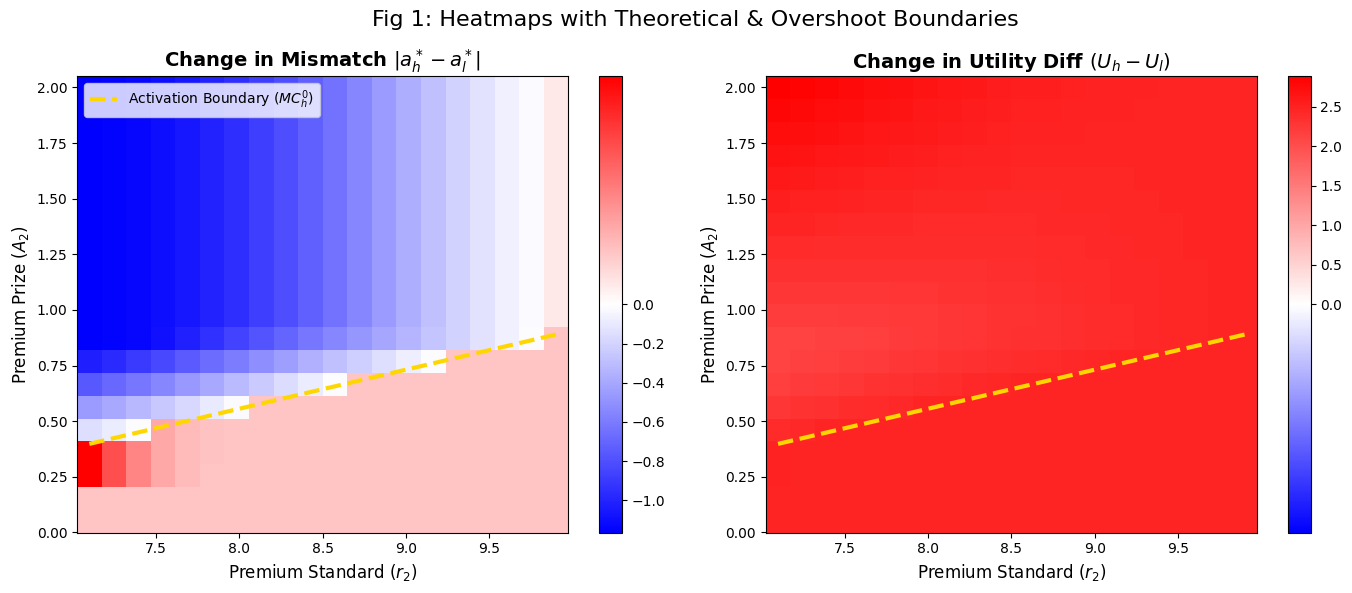

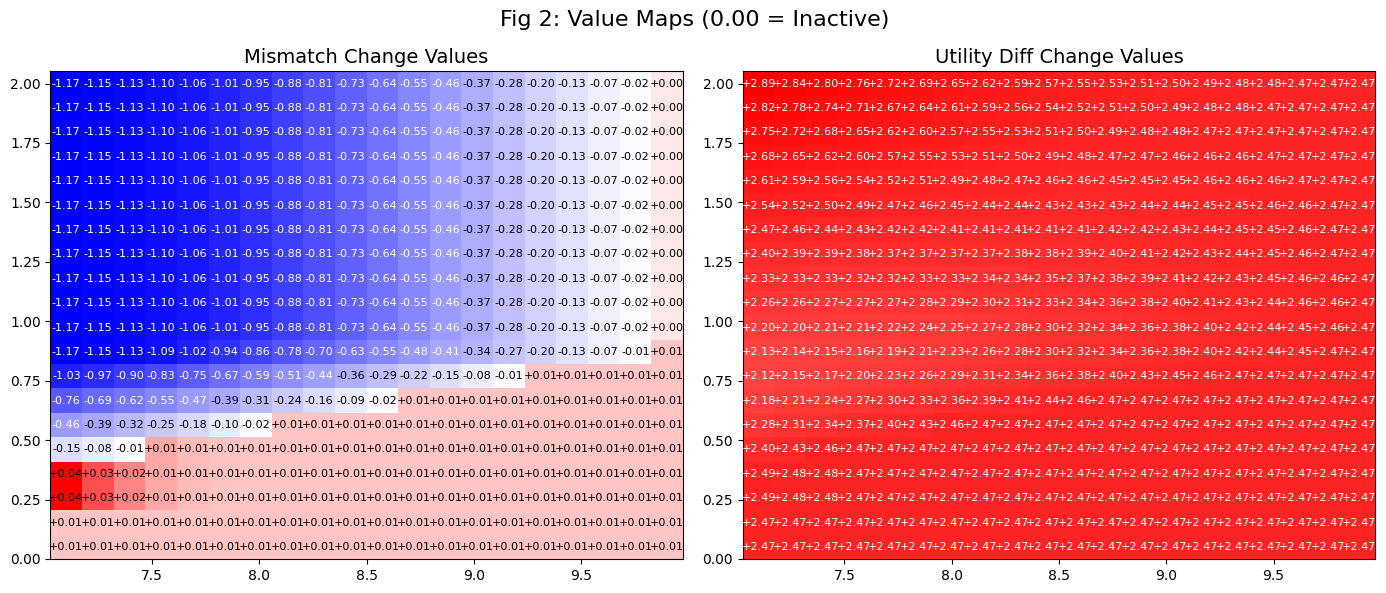

In [37]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root, least_squares
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings

# 忽略积分精度警告以保持控制台干净
warnings.filterwarnings("ignore")

# ==========================================
# 核心求解器模块
# ==========================================
def simulate_market_dynamics(q_h, pdf_h, bar_a_h,
                             q_l, pdf_l, bar_a_l,
                             R, r2, A2, A1=1.0,
                             lr=0.05, tol=1e-6, max_iter=20000):

    # 定义实际的密度函数 (f(x) = q * pdf(x))
    def f_h(x): return q_h * pdf_h(x) if 0 <= x <= bar_a_h else 0.0
    def f_l(x): return q_l * pdf_l(x) if 0 <= x <= bar_a_l else 0.0

    # 预定义生存函数与期望积分 (确保传入的是标量 float)
    def S_h(a): return quad(f_h, float(a), bar_a_h)[0]
    def S_l(a): return quad(f_l, float(a), bar_a_l)[0]
    def int_xf_h(a): return quad(lambda x: x * f_h(x), float(a), bar_a_h)[0]
    def int_xf_l(a): return quad(lambda x: x * f_l(x), float(a), bar_a_l)[0]

    # 寻找 Premium 池的物理上限 W_bar_i
    def find_W_bar(S_func, int_xf_func, bar_a):
        def obj(a):
            a_val = a[0] if isinstance(a, np.ndarray) else a
            s = S_func(a_val)
            if s <= 0: return r2 - bar_a
            return (int_xf_func(a_val) / s) - r2
        res = root(obj, [bar_a - 0.1])
        a2_star = float(res.x[0])
        return S_func(a2_star) if a2_star < bar_a else 0.0

    W_bar_h = find_W_bar(S_h, int_xf_h, bar_a_h)
    W_bar_l = find_W_bar(S_l, int_xf_l, bar_a_l)

    # 核心：给定 (W_h, W_l)，求解子博弈的 (a_h, a_l, r1)
    def solve_subgame(W_h, W_l, init_guess=[5.0, 5.0, 7.0]):
        def equations(vars):
            a_h, a_l, r1 = float(vars[0]), float(vars[1]), float(vars[2])

            # 取消强行截断，交由 least_squares 处理边界
            eq1 = int_xf_h(a_h) - r1 * S_h(a_h) - (r2 - r1) * W_h
            eq2 = int_xf_l(a_l) - r1 * S_l(a_l) - (r2 - r1) * W_l
            eq3 = S_h(a_h) + S_l(a_l) - R
            return [eq1, eq2, eq3]

        # 定义物理边界：a_h 在 [0, bar_a_h]，a_l 在 [0, bar_a_l]，r1 在合理区间内
        upper_r1 = max(bar_a_h, bar_a_l, r2)
        bounds = ([0.0, 0.0, 0.0], [bar_a_h, bar_a_l, upper_r1])

        # 使用原生支持边界的 least_squares
        res = least_squares(equations, init_guess, bounds=bounds, xtol=1e-8, ftol=1e-8)

        return float(res.x[0]), float(res.x[1]), float(res.x[2])

    # ==========================================
    # 核心修复：代数重构后的全局稳定 MC 公式！
    # ==========================================
    def calc_MC(a_h, a_l, r1, W_h, W_l):
        # 确保由于精度误差导致的极小负数被截断为 0
        Q_h = max(0.0, S_h(a_h) - W_h)
        Q_l = max(0.0, S_l(a_l) - W_l)

        # Sender h 的边际成本 (同乘 Q_l，避免除以 Q_l)
        denom_h = Q_l * (r1 - a_h) + Q_h * (r1 - a_l)
        MC_h = (r2 - r1) * Q_l / denom_h if denom_h > 1e-12 else 0.0

        # Sender l 的边际成本 (同乘 Q_h，避免除以 Q_h)
        denom_l = Q_h * (r1 - a_l) + Q_l * (r1 - a_h)
        MC_l = (r2 - r1) * Q_h / denom_l if denom_l > 1e-12 else 0.0

        return MC_h, MC_l

    # 1. Base Game
    a_h_0, a_l_0, r1_0 = solve_subgame(0.0, 0.0)
    Q_h_0, Q_l_0 = S_h(a_h_0), S_l(a_l_0)
    MC_h_0, MC_l_0 = calc_MC(a_h_0, a_l_0, r1_0, 0.0, 0.0)

    base_results = {
        "W_h": 0.0, "W_l": 0.0, "Q_h": Q_h_0, "Q_l": Q_l_0,
        "a_h": a_h_0, "a_l": a_l_0, "r1": r1_0,
        "U_h": A1 * Q_h_0, "U_l": A1 * Q_l_0,
        "MC_h": MC_h_0, "MC_l": MC_l_0
    }

    # 2. Dynamics
    W_h, W_l = 0.0, 0.0
    last_guess = [a_h_0, a_l_0, r1_0]

    for step in range(max_iter):
        a_h, a_l, r1 = solve_subgame(W_h, W_l, init_guess=last_guess)
        last_guess = [a_h, a_l, r1]
        MC_h, MC_l = calc_MC(a_h, a_l, r1, W_h, W_l)

        dW_h = A2/A1 - MC_h
        dW_l = A2/A1 - MC_l

        new_W_h = np.clip(W_h + lr * dW_h, 0.0, float(W_bar_h))
        new_W_l = np.clip(W_l + lr * dW_l, 0.0, float(W_bar_l))

        if abs(new_W_h - W_h) < tol and abs(new_W_l - W_l) < tol:
            W_h, W_l = new_W_h, new_W_l
            break
        W_h, W_l = new_W_h, new_W_l

    # 3. Eq Results
    a_h_star, a_l_star, r1_star = solve_subgame(W_h, W_l, init_guess=last_guess)
    Q_h_star, Q_l_star = S_h(a_h_star) - W_h, S_l(a_l_star) - W_l

    eq_results = {
        "W_h": W_h, "W_l": W_l, "Q_h": Q_h_star, "Q_l": Q_l_star,
        "a_h": a_h_star, "a_l": a_l_star, "r1": r1_star,
        "U_h": (A2 * W_h + A1 * Q_h_star)/q_h, "U_l": (A2 * W_l + A1 * Q_l_star)/q_l,
        "MC_h_final": MC_h, "MC_l_final": MC_l
    }

    return base_results, eq_results

# ==========================================
# 分析与绘图引擎模块
# ==========================================
def run_heatmap_analysis(q_h_val, pdf_h, bar_a_h_val,
                         q_l_val, pdf_l, bar_a_l_val,
                         R_val, A1_val,
                         r2_min, r2_max,
                         A2_min, A2_max,
                         grid_size):

    r2_array = np.linspace(r2_min, r2_max, grid_size)
    A2_array = np.linspace(A2_min, A2_max, grid_size)

    Z_mismatch_change = np.zeros((grid_size, grid_size))
    Z_utility_diff_change = np.zeros((grid_size, grid_size))

    print(f"开始计算 {grid_size}x{grid_size} = {grid_size**2} 个网格点，请稍候...")

    # 提取 Base Game 数据以计算理论边界
    mid_r2 = (r2_min + r2_max) / 2.0
    base_info, _ = simulate_market_dynamics(
        q_h_val, pdf_h, bar_a_h_val, q_l_val, pdf_l, bar_a_l_val, R_val, mid_r2, 0.1, A1_val
    )

    for i, A2_val in enumerate(A2_array):
        for j, r2_val in enumerate(r2_array):
            try:
                # 使用较小的 lr 保证在极其敏感的 Boutique 场景下也能平稳收敛
                base, eq = simulate_market_dynamics(
                    q_h_val, pdf_h, bar_a_h_val, q_l_val, pdf_l, bar_a_l_val,
                    R_val, r2_val, A2_val, A1_val, lr=0.05, max_iter=2000
                )
                Z_mismatch_change[i, j] = abs(eq['a_h'] - eq['a_l']) - abs(base['a_h'] - base['a_l'])
                Z_utility_diff_change[i, j] = (eq['U_h'] - eq['U_l']) - (base['U_h'] - base['U_l'])

            except Exception:
                Z_mismatch_change[i, j], Z_utility_diff_change[i, j] = np.nan, np.nan
        print(f"进度: {i+1}/{grid_size} 行计算完成")

    # ---- 生成网格系 ----
    R2, A2_grid = np.meshgrid(r2_array, A2_array)

    # ---- 逻辑判断 1: 蓝区重合度 (Overlap) ----
    eps = -1e-4
    active_mis = Z_mismatch_change < eps
    active_uti = Z_utility_diff_change < eps
    overlap_rate = np.mean(active_mis == active_uti) * 100

    print("\n=========================================")
    print(f"逻辑验证 1: '效率提升'与'公平改善'的区域重合度为 {overlap_rate:.1f}%")
    print("=========================================\n")

    # ---- 逻辑判断 2: Overshooting 探测 ----
    denominator = (base_info['r1'] - base_info['a_h']) + (base_info['Q_h']/base_info['Q_l'])*(base_info['r1'] - base_info['a_l'])
    theoretical_A2_boundary = A1_val * (r2_array - base_info['r1']) / denominator
    theo_A2_grid = np.tile(theoretical_A2_boundary, (grid_size, 1))

    active_mask = A2_grid > theo_A2_grid
    overshoot_mis_mask = active_mask & (Z_mismatch_change > 0.01)
    overshoot_uti_mask = active_mask & (Z_utility_diff_change > 0.01)

    print("=========================================")
    print("        OVERSHOOTING 逻辑检测")
    print("=========================================")
    if np.any(overshoot_mis_mask) or np.any(overshoot_uti_mask):
        print(f" 检测到 Overshooting 越界点：")
        print(f"  -> Mismatch 恶化网格数: {np.sum(overshoot_mis_mask)}")
        print(f"  -> Utility Diff 恶化网格数: {np.sum(overshoot_uti_mask)}")
        print("结论: 奖金 A2 过高导致提取过度，红区已在图中标出！")
    else:
        print("在当前的 (r2, A2) 参数窗口内，未触发 Overshooting。")
    print("=========================================\n")

    # ---- 绘图部分 ----
    def get_norm(Z):
        vmin, vmax = np.nanmin(Z), np.nanmax(Z)
        if vmax <= 0.0: vmax = 0.01
        if vmin >= 0.0: vmin = -0.01
        return TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

    norm_mis, norm_uti = get_norm(Z_mismatch_change), get_norm(Z_utility_diff_change)
    cmap = plt.get_cmap('bwr')

    fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

    # Mismatch 图
    c1 = axes1[0].pcolormesh(R2, A2_grid, Z_mismatch_change, shading='auto', cmap=cmap, norm=norm_mis)
    axes1[0].plot(r2_array, theoretical_A2_boundary, color='gold', linestyle='dashed', linewidth=3, label=r'Activation Boundary ($MC_h^0$)')
    if np.any(overshoot_mis_mask):
        axes1[0].contour(R2, A2_grid, Z_mismatch_change, levels=[0.01], colors='red', linestyles='solid', linewidths=2, label='Overshoot Boundary')
    axes1[0].set_title('Change in Mismatch $|a_h^* - a_l^*|$', fontsize=14, fontweight='bold')
    axes1[0].set_xlabel('Premium Standard ($r_2$)', fontsize=12)
    axes1[0].set_ylabel('Premium Prize ($A_2$)', fontsize=12)
    axes1[0].legend(loc='upper left')
    fig1.colorbar(c1, ax=axes1[0])

    # Utility 图
    c2 = axes1[1].pcolormesh(R2, A2_grid, Z_utility_diff_change, shading='auto', cmap=cmap, norm=norm_uti)
    axes1[1].plot(r2_array, theoretical_A2_boundary, color='gold', linestyle='dashed', linewidth=3)
    if np.any(overshoot_uti_mask):
        axes1[1].contour(R2, A2_grid, Z_utility_diff_change, levels=[0.01], colors='red', linestyles='solid', linewidths=2)
    axes1[1].set_title('Change in Utility Diff $(U_h - U_l)$', fontsize=14, fontweight='bold')
    axes1[1].set_xlabel('Premium Standard ($r_2$)', fontsize=12)
    axes1[1].set_ylabel('Premium Prize ($A_2$)', fontsize=12)
    fig1.colorbar(c2, ax=axes1[1])

    fig1.suptitle('Fig 1: Heatmaps with Theoretical & Overshoot Boundaries', fontsize=16)
    plt.tight_layout()

    # 带数值的图
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
    axes2[0].pcolormesh(R2, A2_grid, Z_mismatch_change, shading='auto', cmap=cmap, norm=norm_mis)
    axes2[1].pcolormesh(R2, A2_grid, Z_utility_diff_change, shading='auto', cmap=cmap, norm=norm_uti)

    for i in range(grid_size):
        for j in range(grid_size):
            v_mis, v_uti = Z_mismatch_change[i, j], Z_utility_diff_change[i, j]
            t_mis = "0.00" if abs(v_mis) < 1e-4 else f"{v_mis:+.2f}"
            t_uti = "0.00" if abs(v_uti) < 1e-4 else f"{v_uti:+.2f}"

            c_text_m = 'white' if abs(v_mis) > 0.4 else 'black'
            c_text_u = 'white' if abs(v_uti) > 1.0 else 'black'

            axes2[0].text(r2_array[j], A2_array[i], t_mis, ha='center', va='center', fontsize=8, color=c_text_m)
            axes2[1].text(r2_array[j], A2_array[i], t_uti, ha='center', va='center', fontsize=8, color=c_text_u)

    axes2[0].set_title('Mismatch Change Values', fontsize=14)
    axes2[1].set_title('Utility Diff Change Values', fontsize=14)
    fig2.suptitle('Fig 2: Value Maps (0.00 = Inactive)', fontsize=16)
    plt.tight_layout()

    plt.show()

# =========================================================================
# ⬇️ ⬇️ ⬇️ 你可以在这里随意修改所有的输入参数和探索范围！ ⬇️ ⬇️ ⬇️
# =========================================================================
if __name__ == "__main__":

    # 1. 密度函数定义 (Beta 分布)
    from scipy.stats import beta

    def pdf_h_input(x):
        return beta.pdf(x / 10.0, 3, 2) / 10.0

    def pdf_l_input(x):
        return beta.pdf(x / 8.0, 2, 3) / 8.0

    # 2. 市场属性设定
    q_h_input = 2.0        # 优势方总产量
    bar_a_h_input = 10.0   # 优势方质量上限
    q_l_input = 8.0        # 劣势方总产量
    bar_a_l_input = 8.0    # 劣势方质量上限
    R_input = 8.0          # 市场总接收量
    A1_input = 1.0         # 基础奖金

    # 3. 热力图探索边界 (网格范围)
    r2_min_input = 7.1     # Premium 要求期望标准的下界 (必须大于 r1_0)
    r2_max_input = 9.9     # Premium 要求期望标准的上界

    A2_min_input = 0.05    # Premium 额外奖金的下界
    A2_max_input = 2.0     # Premium 额外奖金的上界 (调高以观察 Overshooting)

    # 4. 网格分辨率 (建议保持 12~20，值越大网格越密但算得越久)
    grid_size_input = 20

    # =========================================================================
    # ⬆️ ⬆️ ⬆️ 修改完毕后直接运行，它会自动接管一切计算和绘图！ ⬆️ ⬆️ ⬆️
    # =========================================================================

    # 执行大一统分析函数
    run_heatmap_analysis(
        q_h_val=q_h_input, pdf_h=pdf_h_input, bar_a_h_val=bar_a_h_input,
        q_l_val=q_l_input, pdf_l=pdf_l_input, bar_a_l_val=bar_a_l_input,
        R_val=R_input, A1_val=A1_input,
        r2_min=r2_min_input, r2_max=r2_max_input,
        A2_min=A2_min_input, A2_max=A2_max_input,
        grid_size=grid_size_input
    )